# Loan Approval Prediction - Intermediate Level

## Problem Statement

The objective of this project is to develop a Machine Learning model that predicts whether a loan application will be approved or rejected based on applicant information such as income, credit history, employment status, education, and other financial attributes.

The model aims to assist financial institutions in making data-driven and efficient loan approval decisions.

In [6]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


## Data Collection
The dataset consists of 614 loan application records with 13 features including ApplicantIncome, LoanAmount, Credit_History, Dependents, Education, and Loan_Status (target variable).

In [7]:
#LOADING DATASET
df = pd.read_csv("loan_prediction.csv")
df

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y


## Data Preprocessing
The Loan_ID column was removed as it does not contribute to prediction. 
The '3+' value in the Dependents column was converted to numerical form.
Missing values were handled using median (numerical features) and mode (categorical features).

In [8]:
#BEFORE MISSING VALUES HANDLING
print("Before Missing Values Handling:\nNo.of Missing Values are:")
df.isnull().sum()

Before Missing Values Handling:
No.of Missing Values are:


Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [9]:
#HANDLING MISSING VALUES
for col in df.columns:
    if df[col].dtype == 'object':
        df[col].fillna(df[col].mode()[0], inplace=True)
    else:
        df[col].fillna(df[col].median(), inplace=True)

In [10]:
#AFTER MISSING VALUES HANDLING 
print("After Missing Values Handling:")
df.isnull().sum()

After Missing Values Handling:


Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

## Exploratory Data Analysis
EDA was performed to understand the distribution of loan approvals and examine relationships between income, credit history, and loan amount. 
Correlation analysis helped identify key factors influencing loan approval.

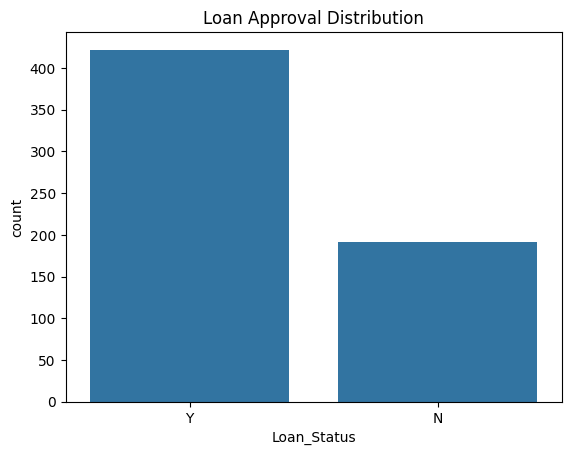

In [11]:
#EDA
#DISTRIBUTION OF LOAN STATUS
sns.countplot(x="Loan_Status", data=df)
plt.title("Loan Approval Distribution")
plt.show()

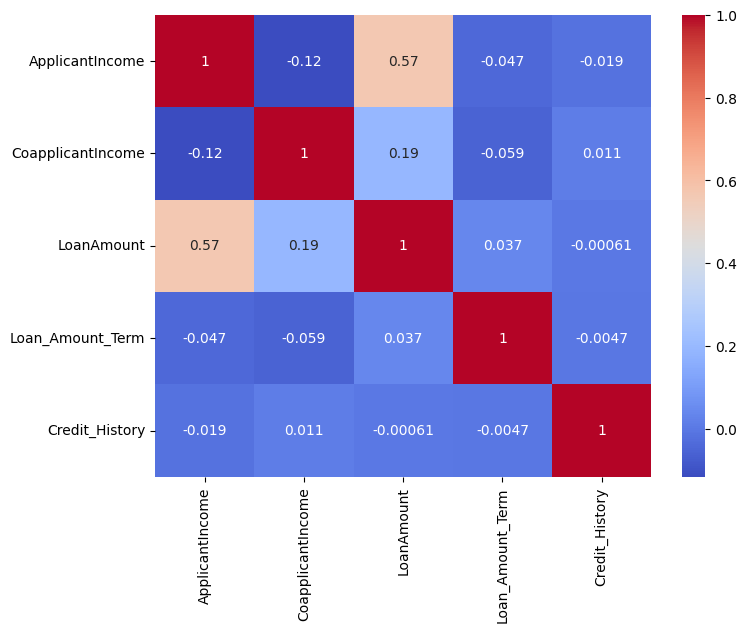

In [12]:
#CORRELATION HEATMAP (NUMERICAL)
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.show()

## Feature Engineering
Categorical variables were converted into numerical format using one-hot encoding. 
The target variable Loan_Status was mapped to binary values (Approved = 1, Rejected = 0).

In [13]:
#FEATURE ENGINEERING
df["Loan_Status"] = df["Loan_Status"].map({"Y":1, "N":0})

In [14]:
#ONE HOT ENCODING
df = pd.get_dummies(df, drop_first=True)
df.head()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,Loan_ID_LP001003,Loan_ID_LP001005,Loan_ID_LP001006,Loan_ID_LP001008,...,Loan_ID_LP002990,Gender_Male,Married_Yes,Dependents_1,Dependents_2,Dependents_3+,Education_Not Graduate,Self_Employed_Yes,Property_Area_Semiurban,Property_Area_Urban
0,5849,0.0,128.0,360.0,1.0,1,0,0,0,0,...,0,1,0,0,0,0,0,0,0,1
1,4583,1508.0,128.0,360.0,1.0,0,1,0,0,0,...,0,1,1,1,0,0,0,0,0,0
2,3000,0.0,66.0,360.0,1.0,1,0,1,0,0,...,0,1,1,0,0,0,0,1,0,1
3,2583,2358.0,120.0,360.0,1.0,1,0,0,1,0,...,0,1,1,0,0,0,1,0,0,1
4,6000,0.0,141.0,360.0,1.0,1,0,0,0,1,...,0,1,0,0,0,0,0,0,0,1


## Data Splitting
The dataset was divided into training and testing sets using an 80:20 split to evaluate model performance on unseen data.

In [15]:
#DATA SPLITTING
X = df.drop("Loan_Status", axis=1)
y = df["Loan_Status"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [16]:
#FEATURE SCALING
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Model Selection and Training
A Random Forest Classifier was selected due to its robustness and ability to handle complex feature interactions. 
The model was trained using the training dataset.

In [17]:
#MODEL TRAINING - RANDOM FOREST CLASSIFIER 
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

## Model Evaluation
The model was evaluated using Accuracy, Confusion Matrix, and Classification Report to measure prediction performance.

In [18]:
#MODEL EVALUATION
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.7886178861788617

Confusion Matrix:
 [[18 25]
 [ 1 79]]

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.42      0.58        43
           1       0.76      0.99      0.86        80

    accuracy                           0.79       123
   macro avg       0.85      0.70      0.72       123
weighted avg       0.83      0.79      0.76       123



## Conclusion

The Random Forest Classifier achieved strong predictive performance in identifying loan approval status.

The model successfully captured patterns related to income, credit history, and applicant characteristics.

This solution can assist financial institutions in automating and improving loan approval decisions.